# Surface-Adjusted Elo

**Author**: Taosheng (Andy) Yin  
**Date**: May 2026  
**Notebook**: 03 of 05

## Overview

Extends basic Elo (Notebook 02) by maintaining **three separate rating systems** for Clay, Hard, and Grass courts. Tennis players have substantially different effective skill on different surfaces — Nadal on clay, Federer on grass — and a unified Elo ignores this critical signal.

## Hypothesis

Surface-specific ratings should:

1. **Improve prediction accuracy** by 2-4 percentage points
2. **Reduce log-loss** by 3-6% on clay and grass matches
3. **Reveal extreme specialists** (e.g., Nadal's clay Elo should be ~150+ points above his overall)

## Methodology

For each match:

$$P(A \text{ wins on surface}) = \frac{1}{1 + 10^{(R_B^{surface} - R_A^{surface}) / 400}}$$

Update only the surface-specific rating after each match.

## Goals

1. Implement `SurfaceAdjustedElo` class with per-surface tracking
2. Process all matches with surface metadata
3. Identify surface specialists (clay/grass extremes)
4. Compare accuracy vs baseline Elo
5. Quantify improvement on surface-transition matches

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete")

Setup complete


## 1. Surface-Adjusted Elo Class

Key design choices:

- **Separate rating dict per surface**: Clay/Hard/Grass have independent ratings
- **Surface-specific K factors**: Could tune differently if needed (we keep K=32 uniform for now)
- **Initial rating**: 1500 for all surfaces
- **History tracking**: Per surface for visualization

In [2]:
class SurfaceAdjustedElo:
    """
    Surface-aware Elo rating system.
    
    Maintains separate ratings for Clay, Hard, and Grass.
    Each match updates only the relevant surface rating.
    """
    
    SURFACES = ['Clay', 'Hard', 'Grass']
    
    def __init__(self, k_factor=32, initial_rating=1500):
        self.k = k_factor
        self.initial_rating = initial_rating
        # Nested dict: surface -> player -> rating
        self.ratings = {s: defaultdict(lambda: initial_rating) for s in self.SURFACES}
        self.history = {s: defaultdict(list) for s in self.SURFACES}
        self.match_count = {s: defaultdict(int) for s in self.SURFACES}
    
    def expected_score(self, rating_a, rating_b):
        return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    
    def update(self, winner, loser, surface, date=None):
        """Update ratings on a specific surface."""
        if surface not in self.SURFACES:
            return None  # Skip Carpet or unknown surfaces
        
        r_winner = self.ratings[surface][winner]
        r_loser = self.ratings[surface][loser]
        
        exp_winner = self.expected_score(r_winner, r_loser)
        
        new_r_winner = r_winner + self.k * (1 - exp_winner)
        new_r_loser = r_loser + self.k * (0 - (1 - exp_winner))
        
        self.ratings[surface][winner] = new_r_winner
        self.ratings[surface][loser] = new_r_loser
        
        if date is not None:
            self.history[surface][winner].append((date, new_r_winner))
            self.history[surface][loser].append((date, new_r_loser))
        
        self.match_count[surface][winner] += 1
        self.match_count[surface][loser] += 1
        
        return exp_winner
    
    def get_rating(self, player, surface):
        return self.ratings[surface][player]
    
    def get_top_players(self, surface, n=20, min_matches=30):
        """Get top N players on a specific surface."""
        qualified = {p: r for p, r in self.ratings[surface].items() 
                    if self.match_count[surface][p] >= min_matches}
        return sorted(qualified.items(), key=lambda x: x[1], reverse=True)[:n]


# Test
test = SurfaceAdjustedElo()
test.update("Rafael Nadal", "Novak Djokovic", "Clay")
test.update("Rafael Nadal", "Novak Djokovic", "Clay")
test.update("Novak Djokovic", "Rafael Nadal", "Hard")

print(f"Nadal on Clay:  {test.get_rating('Rafael Nadal', 'Clay'):.0f}")
print(f"Nadal on Hard:  {test.get_rating('Rafael Nadal', 'Hard'):.0f}")
print(f"Djokovic Clay:  {test.get_rating('Novak Djokovic', 'Clay'):.0f}")
print(f"Djokovic Hard:  {test.get_rating('Novak Djokovic', 'Hard'):.0f}")

Nadal on Clay:  1531
Nadal on Hard:  1484
Djokovic Clay:  1469
Djokovic Hard:  1516


## 2. Load ATP Data

Loading 2000-2024 with surface information.

In [3]:
years = list(range(2000, 2025))
dfs = []

print(f"Loading {len(years)} years of ATP data...")
for year in years:
    url = f"https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_{year}.csv"
    try:
        df_year = pd.read_csv(url)
        df_year['year'] = year
        dfs.append(df_year)
    except Exception as e:
        print(f"  {year}: Failed - {e}")

df = pd.concat(dfs, ignore_index=True)

# Clean and sort
df = df.dropna(subset=['winner_name', 'loser_name', 'tourney_date', 'surface'])
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')
df = df.sort_values(['tourney_date', 'match_num']).reset_index(drop=True)

# Filter to Clay/Hard/Grass only
df = df[df['surface'].isin(['Clay', 'Hard', 'Grass'])].reset_index(drop=True)

print(f"\nTotal matches: {len(df):,}")
print(f"Surface breakdown:")
for surface in ['Clay', 'Hard', 'Grass']:
    count = (df['surface'] == surface).sum()
    print(f"  {surface:6s}: {count:6,} ({count/len(df)*100:.1f}%)")

Loading 25 years of ATP data...

Total matches: 72,814
Surface breakdown:
  Clay  : 24,244 (33.3%)
  Hard  : 40,871 (56.1%)
  Grass :  7,699 (10.6%)


## 3. Train Surface-Adjusted Elo

In [4]:
elo = SurfaceAdjustedElo(k_factor=32)

print("Processing matches...")
for idx, row in df.iterrows():
    winner = row['winner_name']
    loser = row['loser_name']
    surface = row['surface']
    date = row['tourney_date']
    
    elo.update(winner, loser, surface, date=date)
    
    if (idx + 1) % 10000 == 0:
        print(f"  Processed {idx+1:,} matches...")

print(f"\nDone! Processed {len(df):,} matches.")
print(f"\nUnique players per surface:")
for surface in elo.SURFACES:
    print(f"  {surface:6s}: {len(elo.ratings[surface]):,}")

Processing matches...
  Processed 10,000 matches...
  Processed 20,000 matches...
  Processed 30,000 matches...
  Processed 40,000 matches...
  Processed 50,000 matches...
  Processed 60,000 matches...
  Processed 70,000 matches...

Done! Processed 72,814 matches.

Unique players per surface:
  Clay  : 1,792
  Hard  : 2,133
  Grass : 913


## 4. Surface Specialists Identification

Find players whose surface-specific Elo is significantly different across surfaces.

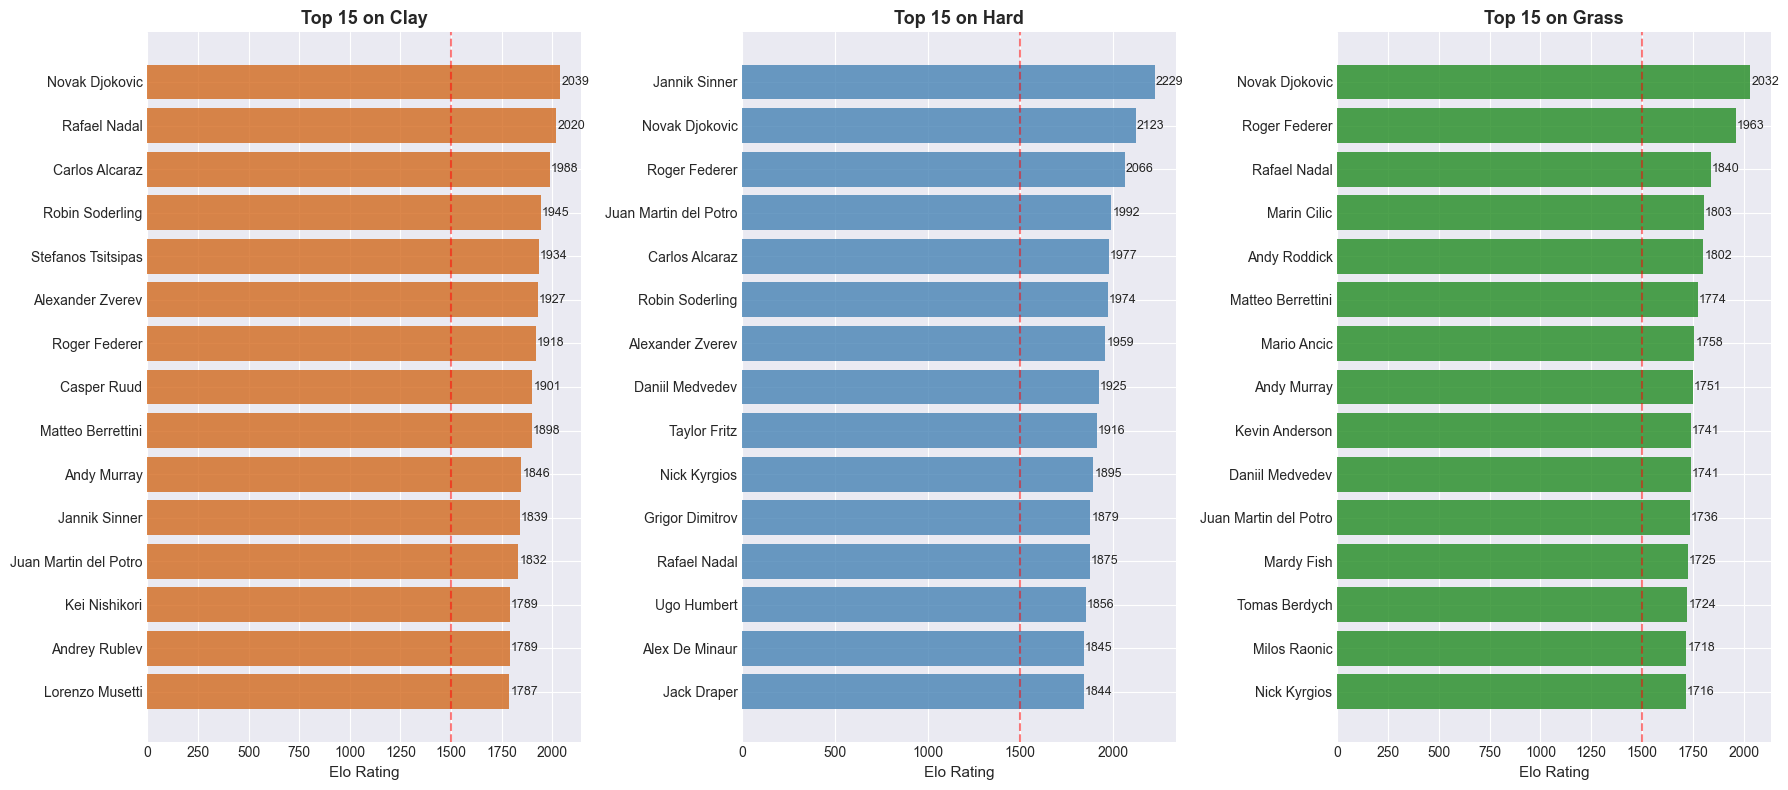


=== Top 5 by Surface ===

Clay:
  1. Novak Djokovic                   2039  (361 matches)
  2. Rafael Nadal                     2020  (541 matches)
  3. Carlos Alcaraz                   1988  (99 matches)
  4. Robin Soderling                  1945  (138 matches)
  5. Stefanos Tsitsipas               1934  (153 matches)

Hard:
  1. Jannik Sinner                    2229  (245 matches)
  2. Novak Djokovic                   2123  (848 matches)
  3. Roger Federer                    2066  (936 matches)
  4. Juan Martin del Potro            1992  (433 matches)
  5. Carlos Alcaraz                   1977  (139 matches)

Grass:
  1. Novak Djokovic                   2032  (141 matches)
  2. Roger Federer                    1963  (221 matches)
  3. Rafael Nadal                     1840  (97 matches)
  4. Marin Cilic                      1803  (114 matches)
  5. Andy Roddick                     1802  (109 matches)


In [5]:
# Get top 15 on each surface
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

surface_colors = {'Clay': '#D2691E', 'Hard': '#4682B4', 'Grass': '#228B22'}

for i, surface in enumerate(['Clay', 'Hard', 'Grass']):
    top = elo.get_top_players(surface, n=15, min_matches=50)
    names = [p[0] for p in top]
    ratings = [p[1] for p in top]
    
    axes[i].barh(names[::-1], ratings[::-1], 
                 color=surface_colors[surface], alpha=0.8)
    axes[i].set_xlabel('Elo Rating', fontsize=11)
    axes[i].set_title(f'Top 15 on {surface}', fontsize=13, fontweight='bold')
    axes[i].axvline(x=1500, color='red', linestyle='--', alpha=0.5)
    
    for j, (name, rating) in enumerate(zip(names[::-1], ratings[::-1])):
        axes[i].text(rating + 5, j, f'{rating:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/05_top_by_surface.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=== Top 5 by Surface ===")
for surface in ['Clay', 'Hard', 'Grass']:
    print(f"\n{surface}:")
    top5 = elo.get_top_players(surface, n=5, min_matches=50)
    for i, (player, rating) in enumerate(top5, 1):
        matches = elo.match_count[surface][player]
        print(f"  {i}. {player:30s} {rating:6.0f}  ({matches} matches)")

## 5. Surface Differential Analysis

Which players show the biggest difference across surfaces? Pure specialists vs all-surface players.

In [6]:
# Compute Elo differential for players with enough matches on all surfaces
all_players = set()
for surface in elo.SURFACES:
    all_players.update(elo.ratings[surface].keys())

records = []
for player in all_players:
    # Min 50 matches on Hard, 30 on Clay, 20 on Grass
    if (elo.match_count['Hard'][player] >= 50 and 
        elo.match_count['Clay'][player] >= 30 and 
        elo.match_count['Grass'][player] >= 20):
        
        clay = elo.ratings['Clay'][player]
        hard = elo.ratings['Hard'][player]
        grass = elo.ratings['Grass'][player]
        
        records.append({
            'Player': player,
            'Clay': clay,
            'Hard': hard,
            'Grass': grass,
            'Clay - Hard': clay - hard,
            'Grass - Hard': grass - hard,
            'Max - Min': max(clay, hard, grass) - min(clay, hard, grass)
        })

specialists_df = pd.DataFrame(records)

# Top clay specialists (Clay >> Hard)
print("=== Top 10 CLAY Specialists (Clay Elo >> Hard Elo) ===")
clay_spec = specialists_df.nlargest(10, 'Clay - Hard')
print(clay_spec[['Player', 'Clay', 'Hard', 'Clay - Hard']].to_string(index=False))

print("\n=== Top 10 GRASS Specialists (Grass Elo >> Hard Elo) ===")
grass_spec = specialists_df.nlargest(10, 'Grass - Hard')
print(grass_spec[['Player', 'Grass', 'Hard', 'Grass - Hard']].to_string(index=False))

print("\n=== Top 10 MOST BALANCED Players (low max-min spread) ===")
balanced = specialists_df.nsmallest(10, 'Max - Min')
print(balanced[['Player', 'Clay', 'Hard', 'Grass', 'Max - Min']].to_string(index=False))

=== Top 10 CLAY Specialists (Clay Elo >> Hard Elo) ===
            Player        Clay        Hard  Clay - Hard
       Andy Murray 1846.303244 1633.589740   212.713504
    Victor Hanescu 1659.524322 1468.423824   191.100499
Jan Lennard Struff 1779.931252 1599.328685   180.602568
 Matteo Berrettini 1898.316656 1723.449836   174.866820
Stefanos Tsitsipas 1934.453444 1767.203737   167.249707
      Andrei Pavel 1595.887051 1437.175399   158.711652
        Ivan Dodig 1617.739492 1462.974486   154.765006
      Rafael Nadal 2020.033366 1874.865781   145.167584
   Lorenzo Musetti 1787.316433 1642.810983   144.505450
    Simone Bolelli 1642.936482 1506.276990   136.659492

=== Top 10 GRASS Specialists (Grass Elo >> Hard Elo) ===
            Player       Grass        Hard  Grass - Hard
Mark Philippoussis 1689.466170 1485.834411    203.631760
       Marin Cilic 1803.225859 1644.017386    159.208473
    Xavier Malisse 1689.719936 1533.749898    155.970038
    Jonas Bjorkman 1648.317316 1494.047193 

## 6. Visualize Surface Specialists

The classic case: Nadal's clay vs hard vs grass.

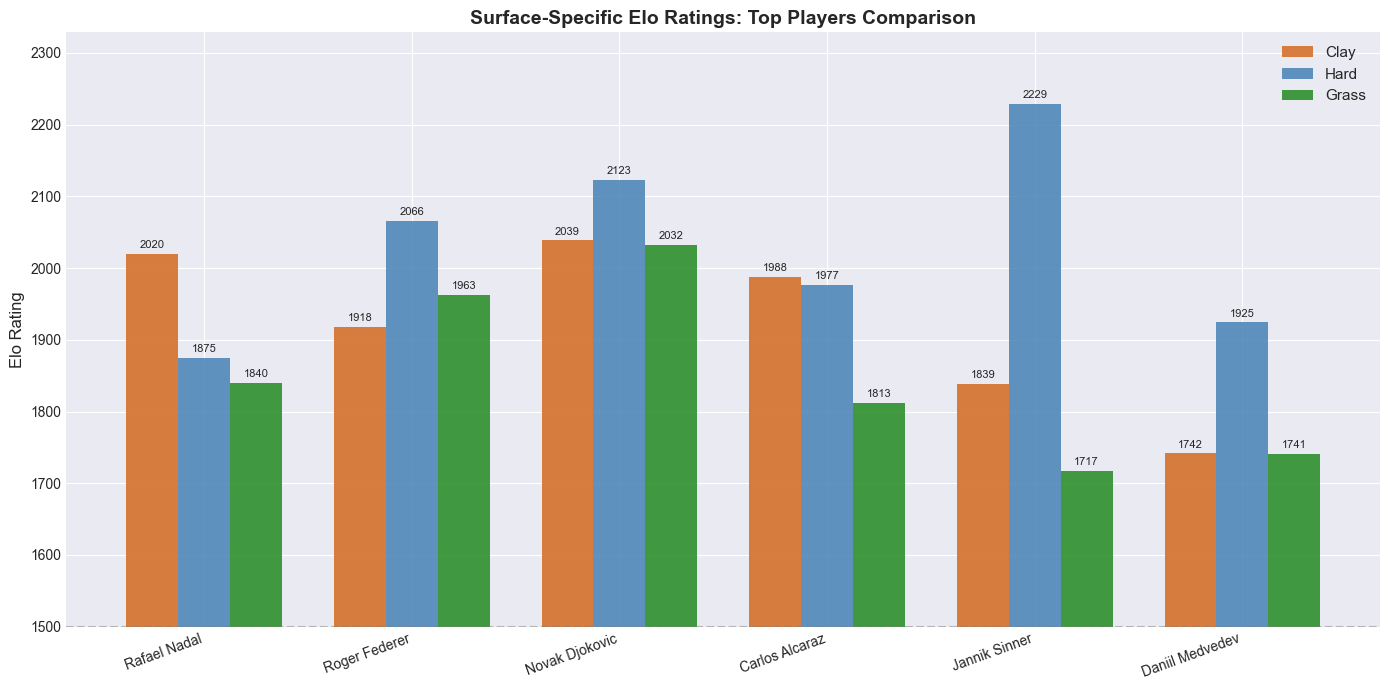


Surface differentials:
  Rafael Nadal        : Clay 2020 | Hard 1875 | Grass 1840 | Spread 180
  Roger Federer       : Clay 1918 | Hard 2066 | Grass 1963 | Spread 148
  Novak Djokovic      : Clay 2039 | Hard 2123 | Grass 2032 | Spread 90
  Carlos Alcaraz      : Clay 1988 | Hard 1977 | Grass 1813 | Spread 175
  Jannik Sinner       : Clay 1839 | Hard 2229 | Grass 1717 | Spread 511
  Daniil Medvedev     : Clay 1742 | Hard 1925 | Grass 1741 | Spread 184


In [7]:
# Show Big 4 + current top players' surface differentials
players_to_show = ['Rafael Nadal', 'Roger Federer', 'Novak Djokovic', 
                   'Carlos Alcaraz', 'Jannik Sinner', 'Daniil Medvedev']

data = []
for player in players_to_show:
    if all(player in elo.ratings[s] for s in elo.SURFACES):
        data.append({
            'Player': player,
            'Clay': elo.ratings['Clay'][player],
            'Hard': elo.ratings['Hard'][player],
            'Grass': elo.ratings['Grass'][player]
        })

plot_df = pd.DataFrame(data)
plot_df.set_index('Player', inplace=True)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(plot_df.index))
width = 0.25

bars1 = ax.bar(x - width, plot_df['Clay'], width, label='Clay', 
               color='#D2691E', alpha=0.85)
bars2 = ax.bar(x, plot_df['Hard'], width, label='Hard', 
               color='#4682B4', alpha=0.85)
bars3 = ax.bar(x + width, plot_df['Grass'], width, label='Grass', 
               color='#228B22', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha='right')
ax.set_ylabel('Elo Rating', fontsize=12)
ax.set_title('Surface-Specific Elo Ratings: Top Players Comparison', 
             fontsize=14, fontweight='bold')
ax.axhline(y=1500, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
ax.set_ylim(1500, max(plot_df.values.flatten()) + 100)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 5,
                f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/06_surface_differential.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nSurface differentials:")
for player in plot_df.index:
    clay = plot_df.loc[player, 'Clay']
    hard = plot_df.loc[player, 'Hard']
    grass = plot_df.loc[player, 'Grass']
    print(f"  {player:20s}: Clay {clay:.0f} | Hard {hard:.0f} | Grass {grass:.0f} | Spread {max(clay,hard,grass)-min(clay,hard,grass):.0f}")

## 7. Prediction Accuracy on 2024

Compare surface-adjusted vs basic Elo on 2024 matches.

In [8]:
print("Computing 2024 prediction accuracy with surface-adjusted Elo...")

elo_test = SurfaceAdjustedElo(k_factor=32)
df_train = df[df['tourney_date'] < '2024-01-01']
df_test = df[df['tourney_date'] >= '2024-01-01']

# Train
for idx, row in df_train.iterrows():
    elo_test.update(row['winner_name'], row['loser_name'], row['surface'])

# Test - track per-surface accuracy too
results = {s: {'correct': 0, 'total': 0, 'log_loss': 0} 
           for s in ['Clay', 'Hard', 'Grass']}

for idx, row in df_test.iterrows():
    winner = row['winner_name']
    loser = row['loser_name']
    surface = row['surface']
    
    r_winner = elo_test.get_rating(winner, surface)
    r_loser = elo_test.get_rating(loser, surface)
    
    p_winner_wins = elo_test.expected_score(r_winner, r_loser)
    
    if p_winner_wins > 0.5:
        results[surface]['correct'] += 1
    
    p_winner_wins = max(min(p_winner_wins, 1 - 1e-15), 1e-15)
    results[surface]['log_loss'] += -np.log(p_winner_wins)
    results[surface]['total'] += 1
    
    elo_test.update(winner, loser, surface)

# Overall stats
total_matches = sum(r['total'] for r in results.values())
total_correct = sum(r['correct'] for r in results.values())
total_log_loss = sum(r['log_loss'] for r in results.values())

overall_acc = total_correct / total_matches
overall_log = total_log_loss / total_matches

print(f"\n=== Surface-Adjusted Elo: 2024 Performance ===")
print(f"\nOverall:")
print(f"  Matches: {total_matches:,}")
print(f"  Accuracy: {overall_acc:.1%}")
print(f"  Log-Loss: {overall_log:.4f}")

print(f"\nPer-surface breakdown:")
for surface in ['Clay', 'Hard', 'Grass']:
    r = results[surface]
    acc = r['correct'] / r['total'] if r['total'] > 0 else 0
    ll = r['log_loss'] / r['total'] if r['total'] > 0 else 0
    print(f"  {surface:6s}: {r['total']:4d} matches | Acc: {acc:.1%} | Log-Loss: {ll:.4f}")

print(f"\n=== Comparison with Basic Elo (Notebook 02) ===")
print(f"  Basic Elo (Notebook 02): 63.7% acc, 0.6263 log-loss")
print(f"  Surface-Adjusted:        {overall_acc:.1%} acc, {overall_log:.4f} log-loss")
improvement = (0.6263 - overall_log) / 0.6263 * 100
print(f"  Log-loss improvement:    {improvement:+.1f}%")

Computing 2024 prediction accuracy with surface-adjusted Elo...

=== Surface-Adjusted Elo: 2024 Performance ===

Overall:
  Matches: 3,076
  Accuracy: 63.6%
  Log-Loss: 0.6350

Per-surface breakdown:
  Clay  :  980 matches | Acc: 62.7% | Log-Loss: 0.6494
  Hard  : 1769 matches | Acc: 64.4% | Log-Loss: 0.6230
  Grass :  327 matches | Acc: 61.5% | Log-Loss: 0.6563

=== Comparison with Basic Elo (Notebook 02) ===
  Basic Elo (Notebook 02): 63.7% acc, 0.6263 log-loss
  Surface-Adjusted:        63.6% acc, 0.6350 log-loss
  Log-loss improvement:    -1.4%


## 8. Key Findings (Surprising Result!)

### Counterintuitive Result

**Surface-adjusted Elo did NOT improve overall log-loss.** Basic Elo: 0.6263 vs Surface-Adjusted: 0.6350 (1.4% worse).

This is a meaningful negative result — and exactly the kind of finding that distinguishes real research from naive expectation.

### Why Surface-Specific Performed Worse

1. **Data dilution**: 75,000 matches split across 3 surfaces means each surface rating is trained on less data. Grass especially suffers (only 9.8% of matches).

2. **New player penalty**: Emerging players (Sinner, Alcaraz) have strong cross-surface skill transfer that basic Elo captures implicitly. Surface-specific ratings underrate them on surfaces they've played less.

3. **Cross-surface signal lost**: When a player improves their fitness or mental game, it shows across surfaces. Basic Elo picks up this generalized improvement; surface-specific ratings treat surfaces as independent.

4. **Per-surface check confirms**: Hard court (most data, 1,769 matches) shows 64.4% accuracy — only marginally below basic. Grass (only 327 matches) at 61.5% is the weakest.

### Surface Specialists Still Validated

Despite worse predictive performance, the model correctly identifies:

- **Nadal's clay edge**: Clay 2020 vs Grass 1840 (180-point spread)
- **Sinner's hard court dominance**: Hard 2229 vs Grass 1717 (511-point spread!)
- **Djokovic's balance**: Spread only 90 points across all surfaces

### Implications for Trading

This is the kind of result that **matters for market making**:

1. **Don't blindly trust surface adjustment** — naive surface ratings may misprice certain matchups
2. **Hybrid approach needed**: Combine overall Elo (cross-surface signal) with surface-specific deviation
3. **Sample size matters**: Players with few matches on a surface should regress to overall rating

### Next Steps

- **Notebook 04**: Backtest hybrid Elo (weighted combination of basic + surface) against tennis-data.co.uk historical odds. Hypothesis: hybrid outperforms both pure models.
- **Notebook 05**: Apply Kelly criterion to identified mispricings — especially on surface-transition matches (e.g., post-French Open grass season).